#📌 Extracción

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Configurar pandas para mostrar todas las columnas
pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_json('https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json')
df

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
...,...,...,...,...,...,...
7262,9987-LUTYD,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
7263,9992-RRAMN,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7264,9992-UJOEL,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7265,9993-LHIEB,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Two year', 'PaperlessBilling': '..."


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


In [4]:
df.dtypes

,0
customerID,object
Churn,object
customer,object
phone,object
internet,object
account,object


#🔧 Transformación

In [5]:
# Transformar la columna Churn a booleano y asegurar el tipo de dato
df['Churn'] = df['Churn'].map({'Yes': True, 'No': False}).astype(bool)

display(df[['customerID', 'Churn']].head())

,customerID,Churn
0,0002-ORFBO,False
1,0003-MKNFE,False
2,0004-TLHLJ,True
3,0011-IGKFF,True
4,0013-EXCHZ,True


In [6]:
# Expandir la columna 'customer' que contiene diccionarios
customer_columns = pd.json_normalize(df['customer'])

# Concatenar las nuevas columnas y eliminar la original
df = pd.concat([df.drop(columns=['customer']), customer_columns], axis=1)


In [7]:
# Transformar SeniorCitizen a booleano
df['SeniorCitizen'] = df['SeniorCitizen'].astype(bool)

# Verificar el cambio
display(df[['customerID', 'SeniorCitizen']].head())

,customerID,SeniorCitizen
0,0002-ORFBO,False
1,0003-MKNFE,False
2,0004-TLHLJ,False
3,0011-IGKFF,True
4,0013-EXCHZ,True


In [8]:
# Transformar Partner y Dependents a booleano
for col in ['Partner', 'Dependents']:
    df[col] = df[col].map({'Yes': True, 'No': False}).astype(bool)

In [9]:
# Expandir las columnas restantes que contienen diccionarios
for col in ['phone', 'internet', 'account']:
    expanded_cols = pd.json_normalize(df[col])
    df = pd.concat([df.drop(columns=[col]), expanded_cols], axis=1)

display(df.head())

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,False,Female,False,True,True,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,False,Male,False,False,False,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,True,Male,False,False,False,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,True,Male,True,True,False,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,True,Female,True,True,False,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [10]:
# Lista de columnas de servicios de internet a transformar
internet_services = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

# Transformar a booleano: 'Yes' -> True, otros -> False
for col in internet_services:
    df[col] = df[col].map({'Yes': True, 'No': False, 'No internet service': False}).astype(bool)

In [11]:
# Transformar PhoneService y MultipleLines a booleano
# Para MultipleLines, 'No phone service' se tratará como False
df['PhoneService'] = df['PhoneService'].map({'Yes': True, 'No': False}).astype(bool)
df['MultipleLines'] = df['MultipleLines'].map({'Yes': True, 'No': False, 'No phone service': False}).astype(bool)

In [12]:
# Transformar PaperlessBilling a booleano
df['PaperlessBilling'] = df['PaperlessBilling'].map({'Yes': True, 'No': False}).astype(bool)

In [13]:
df

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,False,Female,False,True,True,9,True,False,DSL,False,True,False,True,True,False,One year,True,Mailed check,65.60,593.3
1,0003-MKNFE,False,Male,False,False,False,9,True,True,DSL,False,False,False,False,False,True,Month-to-month,False,Mailed check,59.90,542.4
2,0004-TLHLJ,True,Male,False,False,False,4,True,False,Fiber optic,False,False,True,False,False,False,Month-to-month,True,Electronic check,73.90,280.85
3,0011-IGKFF,True,Male,True,True,False,13,True,False,Fiber optic,False,True,True,False,True,True,Month-to-month,True,Electronic check,98.00,1237.85
4,0013-EXCHZ,True,Female,True,True,False,3,True,False,Fiber optic,False,False,False,True,True,False,Month-to-month,True,Mailed check,83.90,267.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,False,Female,False,False,False,13,True,False,DSL,True,False,False,True,False,False,One year,False,Mailed check,55.15,742.9
7263,9992-RRAMN,True,Male,False,True,False,22,True,True,Fiber optic,False,False,False,False,False,True,Month-to-month,True,Electronic check,85.10,1873.7
7264,9992-UJOEL,False,Male,False,False,False,2,True,False,DSL,False,True,False,False,False,False,Month-to-month,True,Mailed check,50.30,92.75
7265,9993-LHIEB,False,Male,False,True,True,67,True,False,DSL,True,False,True,True,False,True,Two year,False,Mailed check,67.85,4627.65


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   bool   
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   bool   
 4   Partner           7267 non-null   bool   
 5   Dependents        7267 non-null   bool   
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   bool   
 8   MultipleLines     7267 non-null   bool   
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   bool   
 11  OnlineBackup      7267 non-null   bool   
 12  DeviceProtection  7267 non-null   bool   
 13  TechSupport       7267 non-null   bool   
 14  StreamingTV       7267 non-null   bool   
 15  StreamingMovies   7267 non-null   bool   
 16  Contract          7267 non-null   object 


In [15]:
# Transformar Charges.Total a float, convirtiendo blancos/errores en 0
df['Charges.Total'] = pd.to_numeric(df['Charges.Total'], errors='coerce').fillna(0)

In [16]:
# Calcular el cargo diario basado en la facturación mensual (asumiendo mes de 30 días)
df['Cuentas_Diarias'] = df['Charges.Monthly'] / 30

# Mostrar las primeras filas con la nueva columna y los cargos mensuales para comparar
display(df[['customerID', 'Charges.Monthly', 'Cuentas_Diarias']].head())

display(df['Cuentas_Diarias'].describe())

,customerID,Charges.Monthly,Cuentas_Diarias
0,0002-ORFBO,65.6,2.186667
1,0003-MKNFE,59.9,1.996667
2,0004-TLHLJ,73.9,2.463333
3,0011-IGKFF,98.0,3.266667
4,0013-EXCHZ,83.9,2.796667


,Cuentas_Diarias
count,7267.000000
mean,2.157337
std,1.004319
min,0.608333
25%,1.180833
50%,2.343333
75%,2.995833
max,3.958333


In [17]:
df

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total,Cuentas_Diarias
0,0002-ORFBO,False,Female,False,True,True,9,True,False,DSL,False,True,False,True,True,False,One year,True,Mailed check,65.60,593.30,2.186667
1,0003-MKNFE,False,Male,False,False,False,9,True,True,DSL,False,False,False,False,False,True,Month-to-month,False,Mailed check,59.90,542.40,1.996667
2,0004-TLHLJ,True,Male,False,False,False,4,True,False,Fiber optic,False,False,True,False,False,False,Month-to-month,True,Electronic check,73.90,280.85,2.463333
3,0011-IGKFF,True,Male,True,True,False,13,True,False,Fiber optic,False,True,True,False,True,True,Month-to-month,True,Electronic check,98.00,1237.85,3.266667
4,0013-EXCHZ,True,Female,True,True,False,3,True,False,Fiber optic,False,False,False,True,True,False,Month-to-month,True,Mailed check,83.90,267.40,2.796667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,False,Female,False,False,False,13,True,False,DSL,True,False,False,True,False,False,One year,False,Mailed check,55.15,742.90,1.838333
7263,9992-RRAMN,True,Male,False,True,False,22,True,True,Fiber optic,False,False,False,False,False,True,Month-to-month,True,Electronic check,85.10,1873.70,2.836667
7264,9992-UJOEL,False,Male,False,False,False,2,True,False,DSL,False,True,False,False,False,False,Month-to-month,True,Mailed check,50.30,92.75,1.676667
7265,9993-LHIEB,False,Male,False,True,True,67,True,False,DSL,True,False,True,True,False,True,Two year,False,Mailed check,67.85,4627.65,2.261667


#📊 Carga y análisis

In [18]:
df.describe()

,tenure,Charges.Monthly,Charges.Total,Cuentas_Diarias
count,7267.000000,7267.000000,7267.000000,7267.000000
mean,32.346498,64.720098,2277.182035,2.157337
std,24.571773,30.129572,2268.648587,1.004319
min,0.000000,18.250000,0.000000,0.608333
25%,9.000000,35.425000,396.200000,1.180833
50%,29.000000,70.300000,1389.200000,2.343333
75%,55.000000,89.875000,3778.525000,2.995833
max,72.000000,118.750000,8684.800000,3.958333


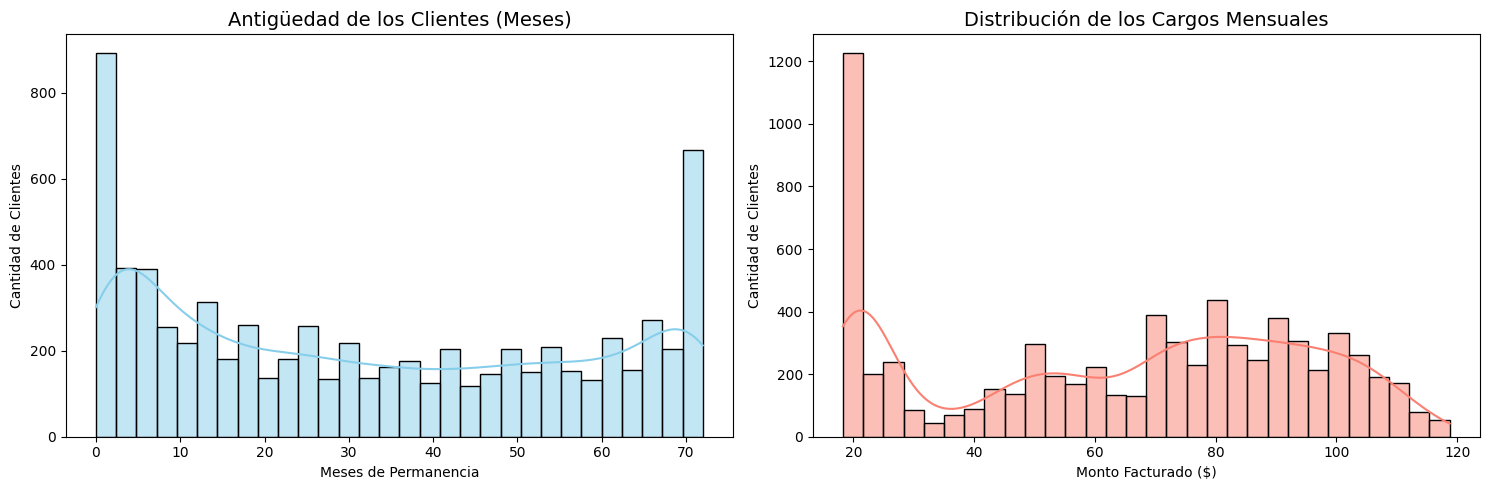

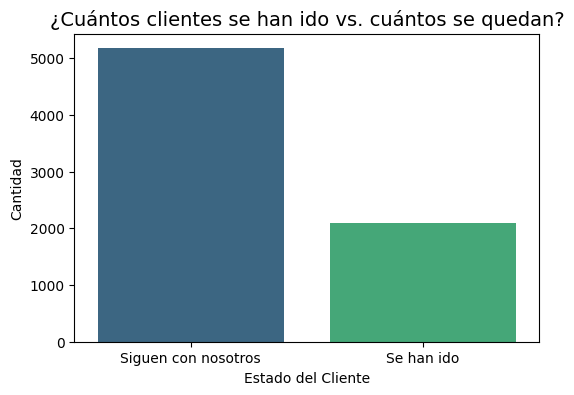

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Visualización de la distribución de variables clave
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Distribución de Tenure
sns.histplot(df['tenure'], bins=30, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Antigüedad de los Clientes (Meses)', fontsize=14)
axes[0].set_xlabel('Meses de Permanencia')
axes[0].set_ylabel('Cantidad de Clientes')

# Distribución de Charges.Monthly
sns.histplot(df['Charges.Monthly'], bins=30, kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribución de los Cargos Mensuales', fontsize=14)
axes[1].set_xlabel('Monto Facturado ($)')
axes[1].set_ylabel('Cantidad de Clientes')

plt.tight_layout()
plt.show()

# 2. Distribución de Churn (Variable Objetivo)
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df, palette='viridis', hue='Churn', legend=False)
plt.title('¿Cuántos clientes se han ido vs. cuántos se quedan?', fontsize=14)
plt.xticks([0, 1], ['Siguen con nosotros', 'Se han ido'])
plt.xlabel('Estado del Cliente')
plt.ylabel('Cantidad')
plt.show()

/tmp/ipykernel_1079/1316786464.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['No', 'Sí'])
/tmp/ipykernel_1079/1316786464.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['No', 'Sí'])
/tmp/ipykernel_1079/1316786464.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['No', 'Sí'])


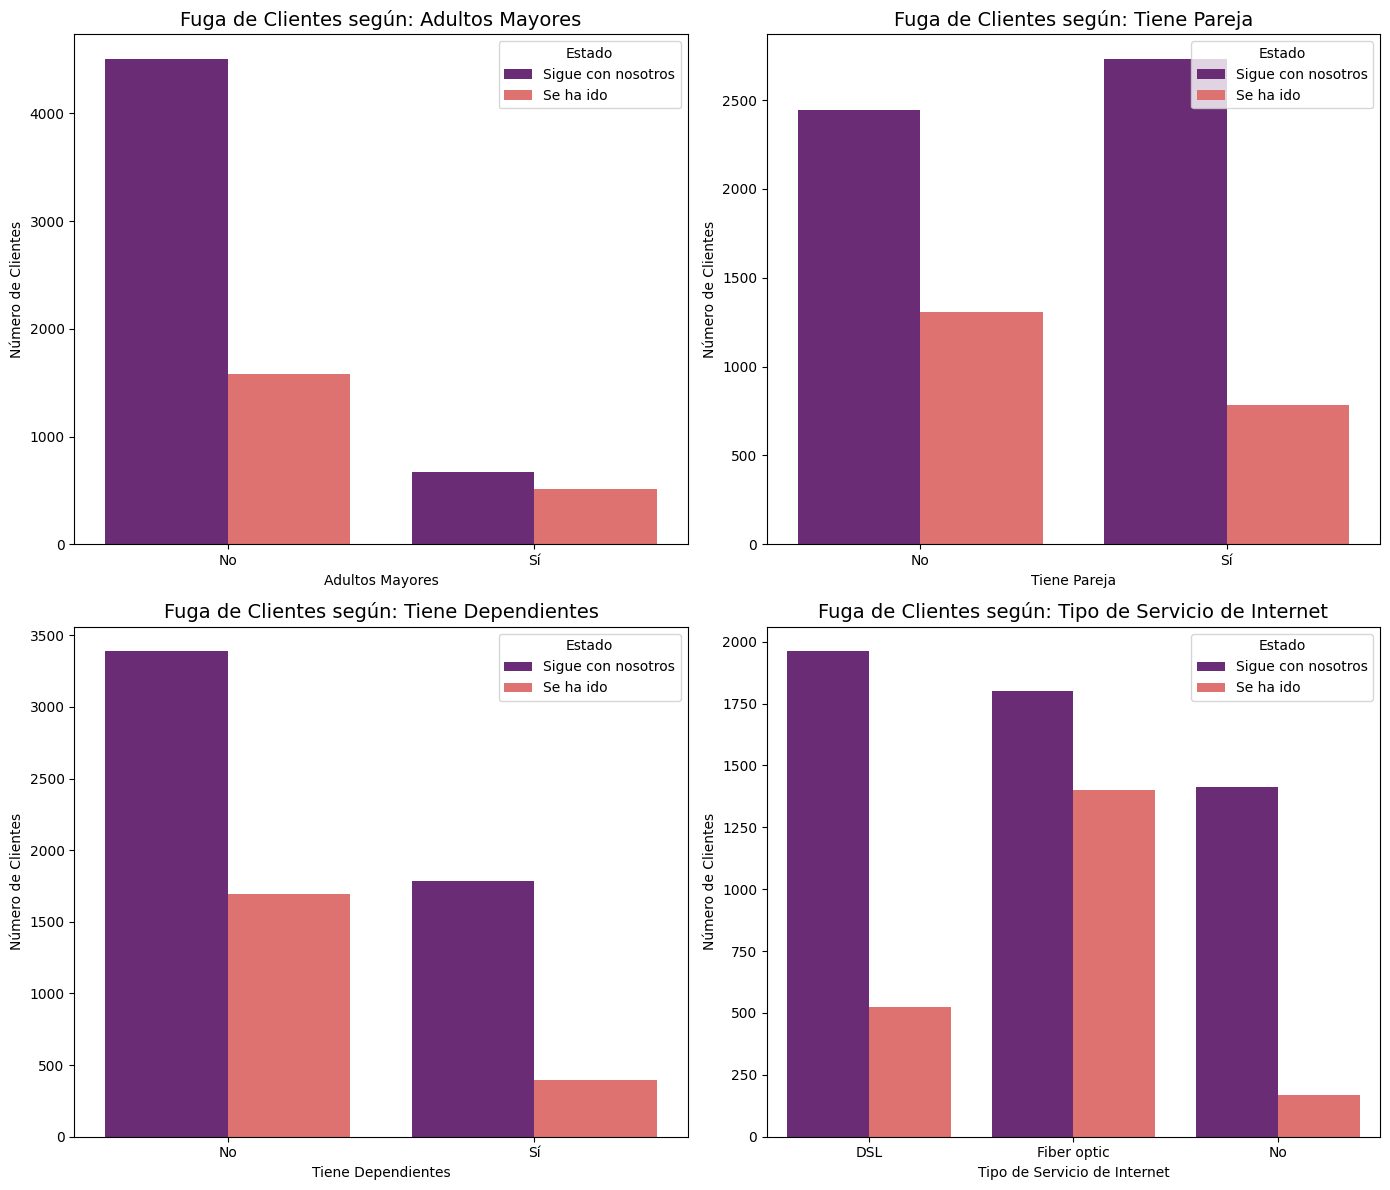

In [20]:
# Definir variables adicionales y mapeos de lenguaje natural
extra_features = ['SeniorCitizen', 'Partner', 'Dependents', 'InternetService']
titles = {
    'SeniorCitizen': 'Adultos Mayores',
    'Partner': 'Tiene Pareja',
    'Dependents': 'Tiene Dependientes',
    'InternetService': 'Tipo de Servicio de Internet'
}

# Crear la figura
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 12))
axes = axes.flatten()

for i, col in enumerate(extra_features):
    ax = sns.countplot(data=df, x=col, hue='Churn', ax=axes[i], palette='magma')
    axes[i].set_title(f'Fuga de Clientes según: {titles[col]}', fontsize=14)
    axes[i].set_xlabel(titles[col])
    axes[i].set_ylabel('Número de Clientes')

    # Traducir etiquetas de los ejes X para booleanos
    if col in ['SeniorCitizen', 'Partner', 'Dependents']:
        axes[i].set_xticklabels(['No', 'Sí'])

    # Ajustar leyenda
    h, l = ax.get_legend_handles_labels()
    ax.legend(h, ['Sigue con nosotros', 'Se ha ido'], title='Estado', loc='upper right')

plt.tight_layout()
plt.show()

/tmp/ipykernel_1079/4235528333.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=col, y='Churn', ax=axes[i], palette='coolwarm', errorbar=None)
/tmp/ipykernel_1079/4235528333.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['No', 'Sí'])
/tmp/ipykernel_1079/4235528333.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=col, y='Churn', ax=axes[i], palette='coolwarm', errorbar=None)
/tmp/ipykernel_1079/4235528333.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].

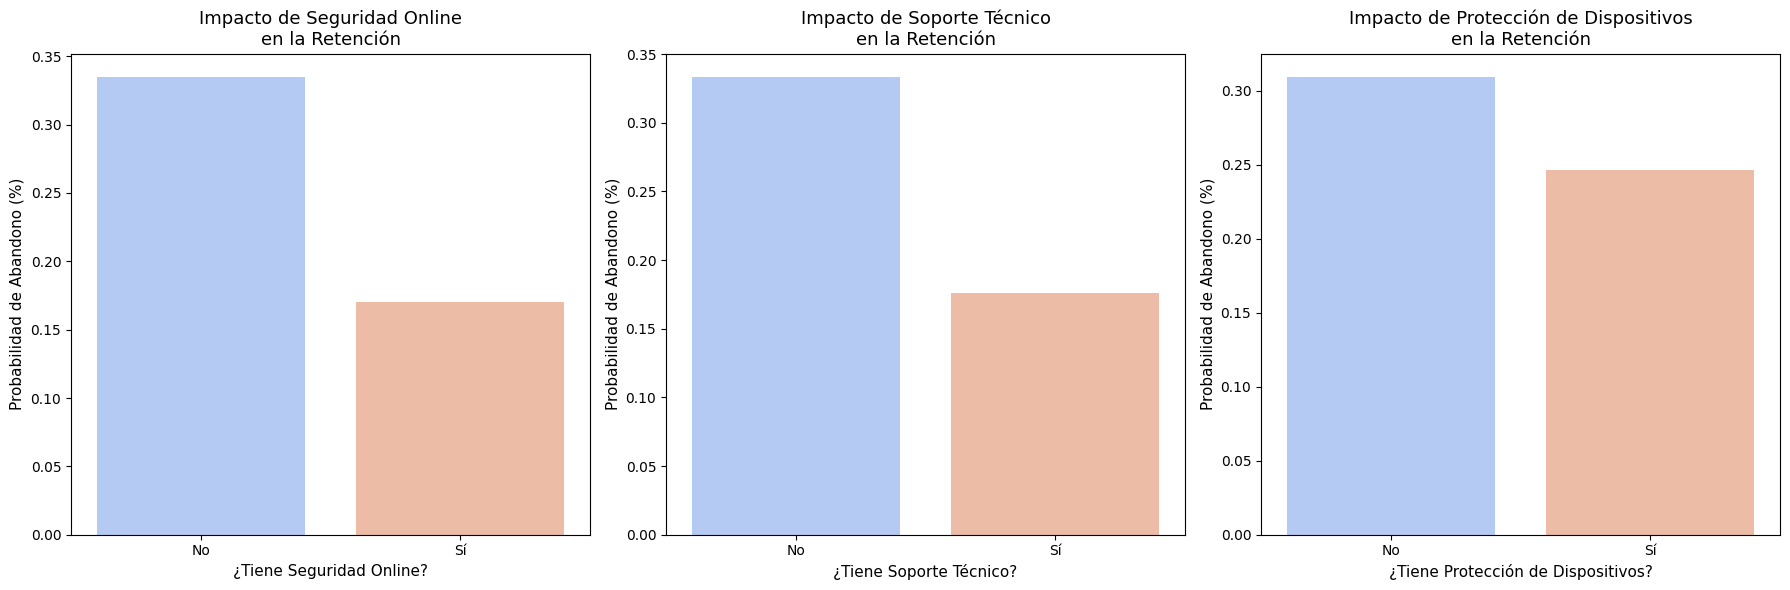

In [21]:
# Visualización de servicios con etiquetas amigables
service_map = {
    'OnlineSecurity': 'Seguridad Online',
    'TechSupport': 'Soporte Técnico',
    'DeviceProtection': 'Protección de Dispositivos'
}

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 6))

for i, col in enumerate(service_map.keys()):
    sns.barplot(data=df, x=col, y='Churn', ax=axes[i], palette='coolwarm', errorbar=None)
    axes[i].set_title(f'Impacto de {service_map[col]}\nen la Retención', fontsize=13)
    axes[i].set_xlabel(f'¿Tiene {service_map[col]}?', fontsize=11)
    axes[i].set_ylabel('Probabilidad de Abandono (%)', fontsize=11)
    axes[i].set_xticklabels(['No', 'Sí'])

plt.tight_layout()
plt.show()

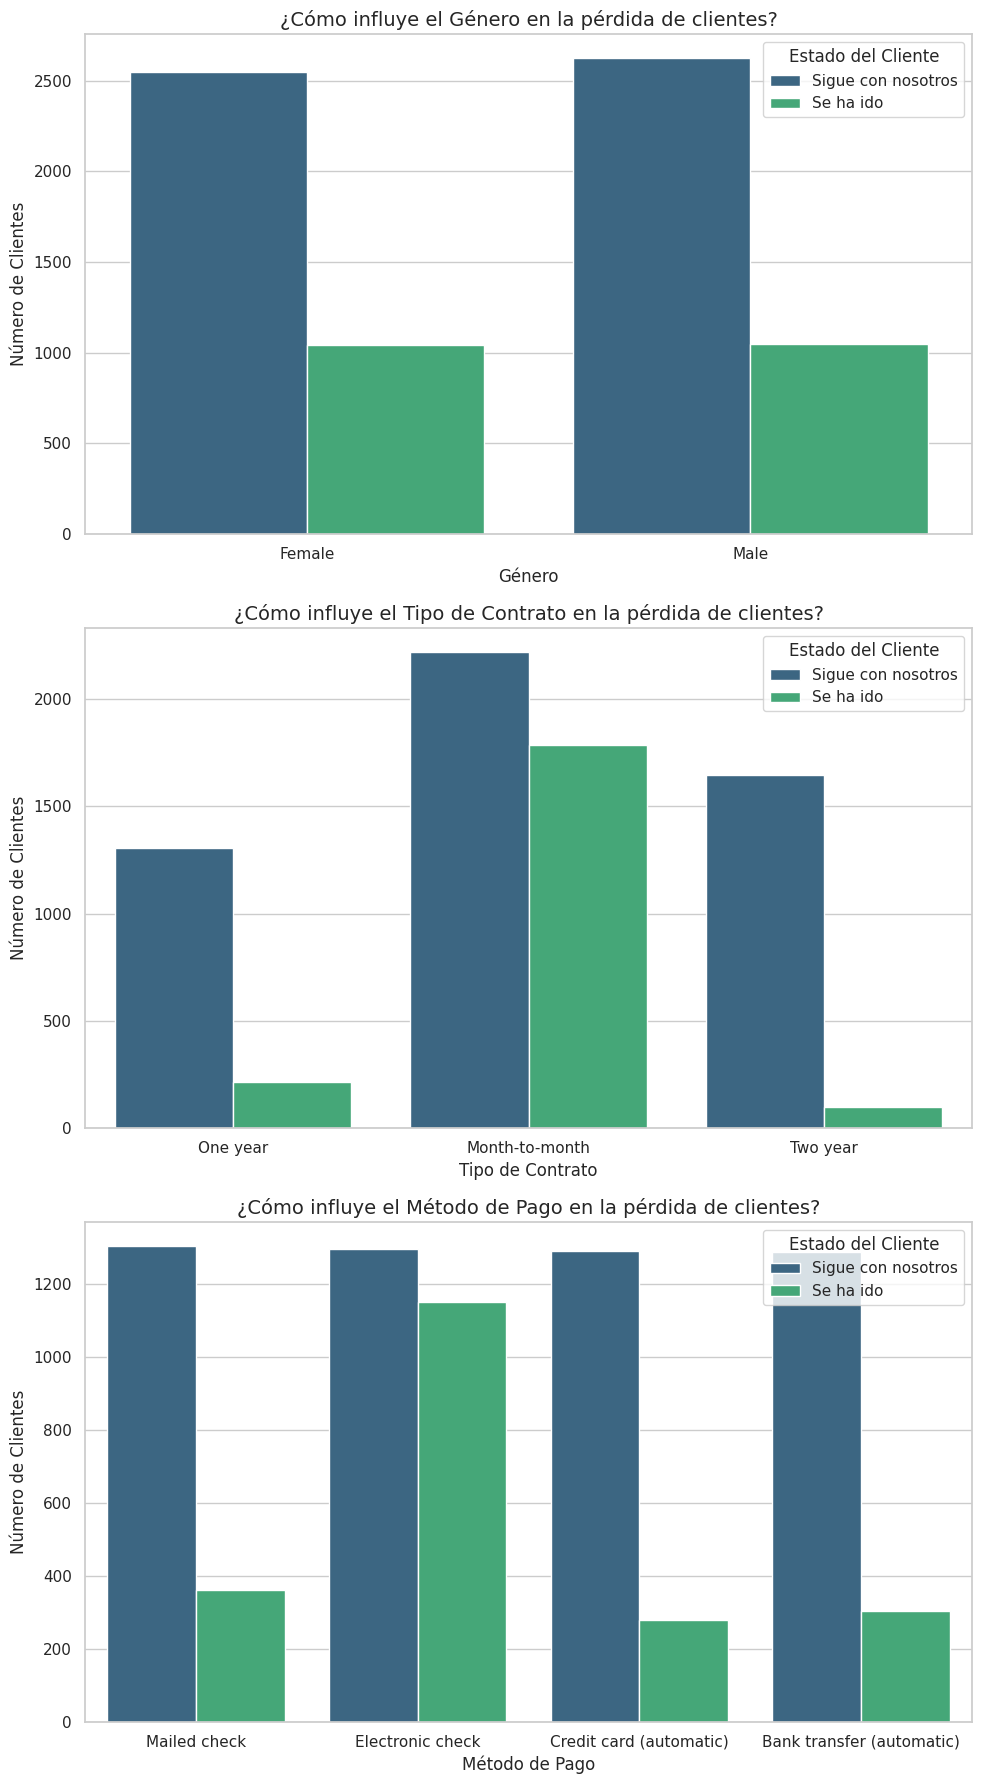

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# Configurar el estilo
sns.set_theme(style='whitegrid')

# Diccionario para traducir variables y categorías
traduc_cols = {
    'gender': 'Género',
    'Contract': 'Tipo de Contrato',
    'PaymentMethod': 'Método de Pago',
    'Churn': 'Fuga de Clientes'
}

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 18))

features = ['gender', 'Contract', 'PaymentMethod']
for i, col in enumerate(features):
    ax = sns.countplot(data=df, x=col, hue='Churn', ax=axes[i], palette='viridis')
    axes[i].set_title(f'¿Cómo influye el {traduc_cols[col]} en la pérdida de clientes?', fontsize=14)
    axes[i].set_xlabel(traduc_cols[col], fontsize=12)
    axes[i].set_ylabel('Número de Clientes', fontsize=12)

    # Ajustar leyenda
    legend_labels = ['Sigue con nosotros', 'Se ha ido']
    h, l = ax.get_legend_handles_labels()
    ax.legend(h, legend_labels, title='Estado del Cliente', loc='upper right')

plt.tight_layout()
plt.show()



--- GRUPO 1: DISTRIBUCIONES GENERALES ---




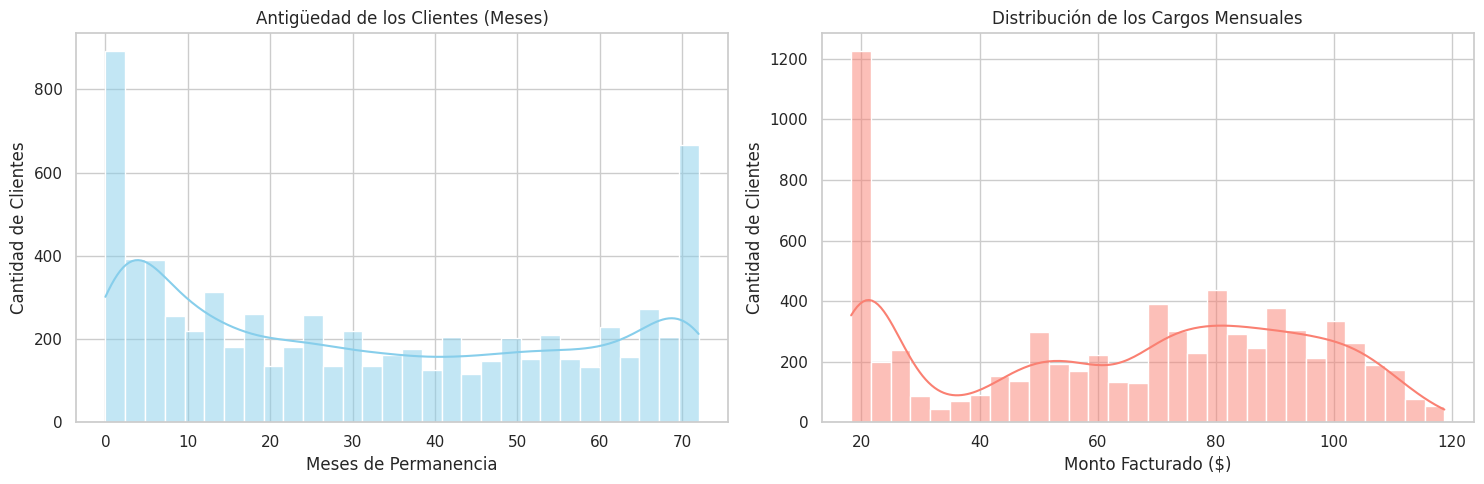



--- GRUPO 2: PERFIL DEMOGRÁFICO Y FUGA ---




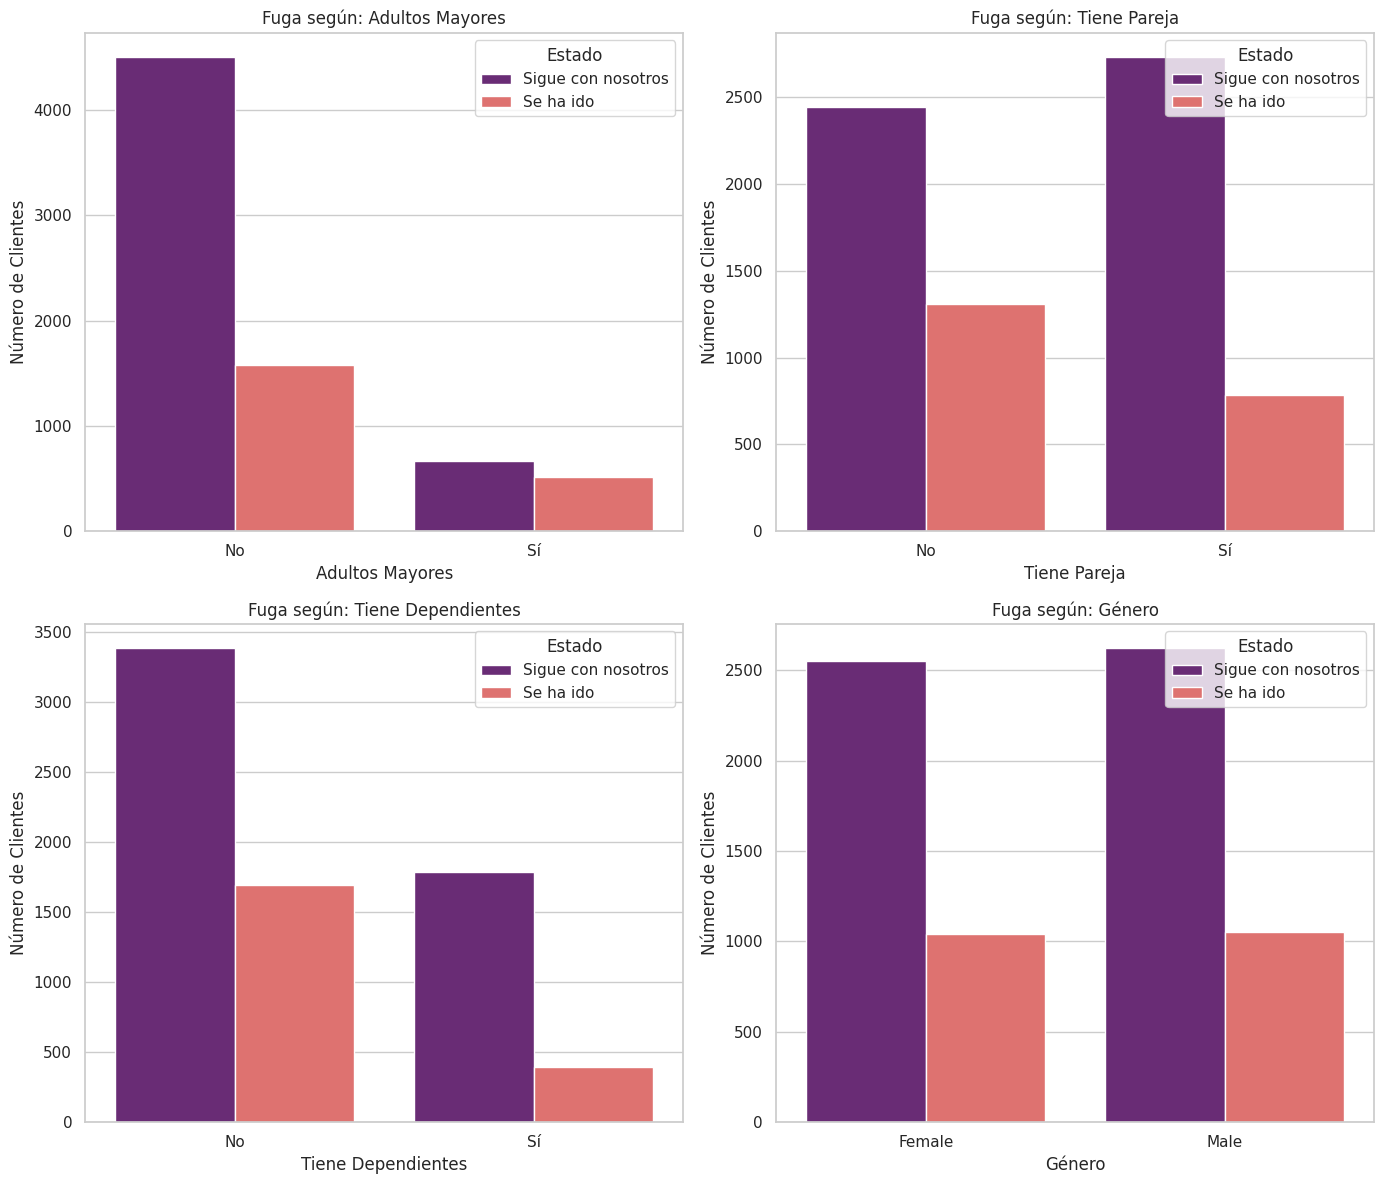



--- GRUPO 3: CONTRATOS, PAGOS Y SERVICIOS ---




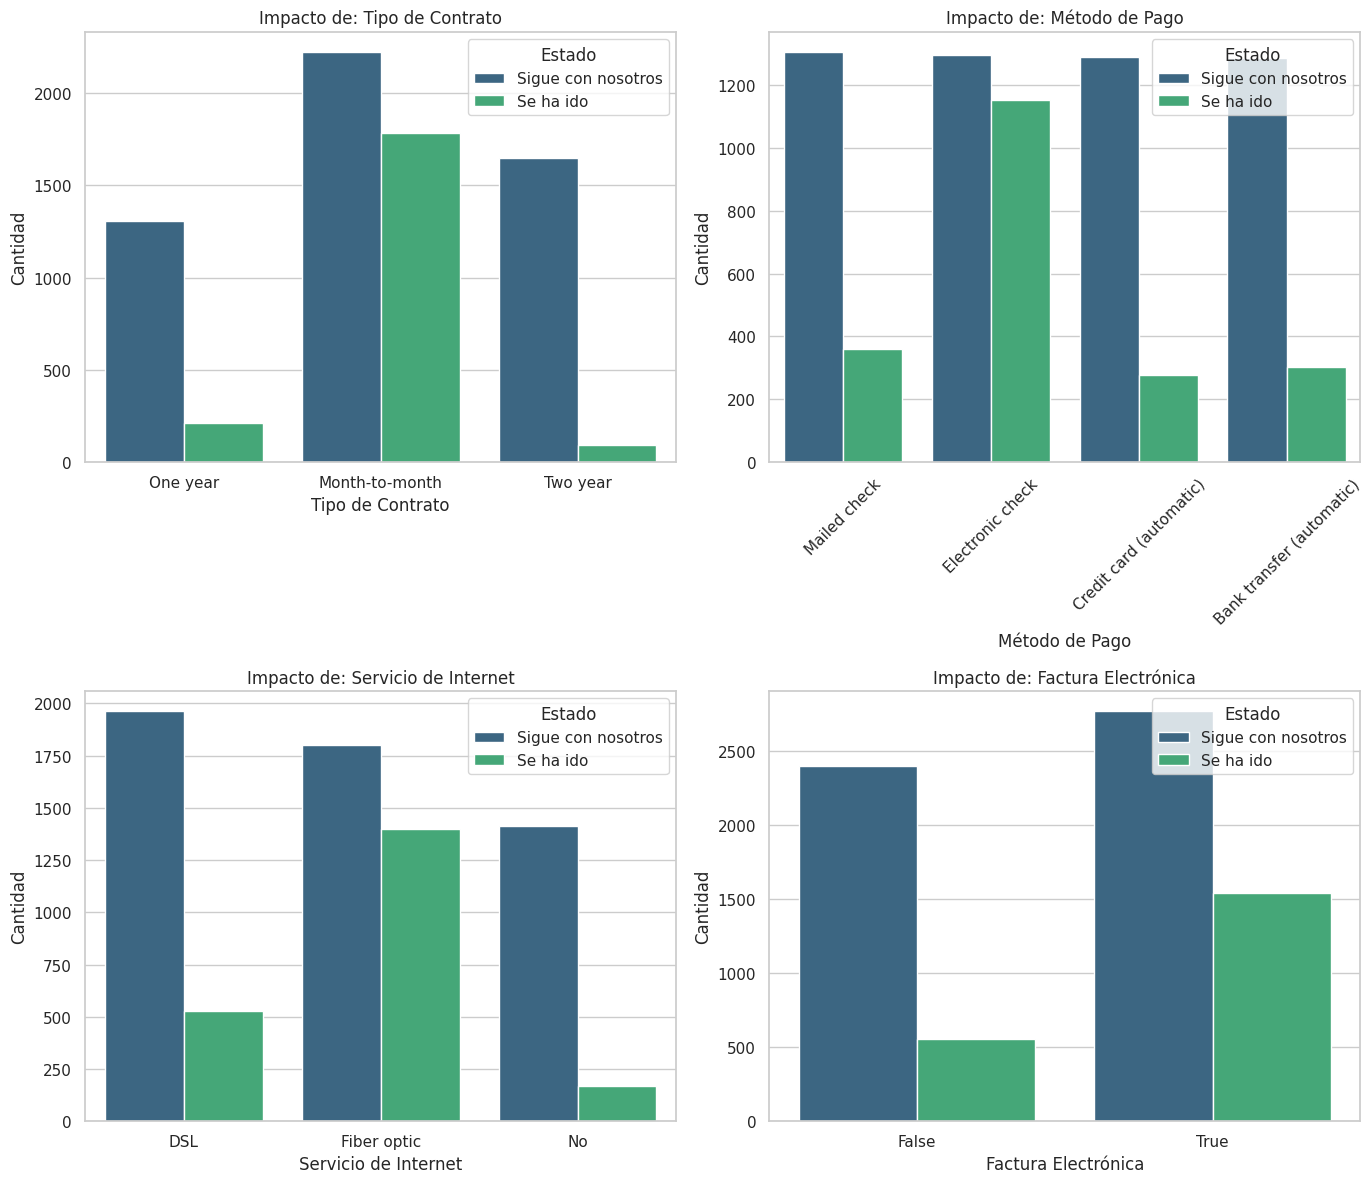

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

# Desactivar warnings de visualización
warnings.filterwarnings('ignore')

# Configuración estética general
sns.set_theme(style='whitegrid')
plt.rcParams['figure.titlesize'] = 16

print('\n\n--- GRUPO 1: DISTRIBUCIONES GENERALES ---\n\n')
fig1, axes1 = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df['tenure'], bins=30, kde=True, ax=axes1[0], color='skyblue')
axes1[0].set_title('Antigüedad de los Clientes (Meses)')
axes1[0].set_xlabel('Meses de Permanencia')
axes1[0].set_ylabel('Cantidad de Clientes')

sns.histplot(df['Charges.Monthly'], bins=30, kde=True, ax=axes1[1], color='salmon')
axes1[1].set_title('Distribución de los Cargos Mensuales')
axes1[1].set_xlabel('Monto Facturado ($)')
axes1[1].set_ylabel('Cantidad de Clientes')

plt.tight_layout()
plt.show()

print('\n\n--- GRUPO 2: PERFIL DEMOGRÁFICO Y FUGA ---\n\n')
extra_features = ['SeniorCitizen', 'Partner', 'Dependents', 'gender']
titles = {
    'SeniorCitizen': 'Adultos Mayores',
    'Partner': 'Tiene Pareja',
    'Dependents': 'Tiene Dependientes',
    'gender': 'Género'
}

fig2, axes2 = plt.subplots(nrows=2, ncols=2, figsize=(14, 12))
axes2 = axes2.flatten()

for i, col in enumerate(extra_features):
    ax = sns.countplot(data=df, x=col, hue='Churn', ax=axes2[i], palette='magma')
    axes2[i].set_title(f'Fuga según: {titles[col]}')
    axes2[i].set_xlabel(titles[col])
    axes2[i].set_ylabel('Número de Clientes')

    if col in ['SeniorCitizen', 'Partner', 'Dependents']:
        axes2[i].set_xticks([0, 1])
        axes2[i].set_xticklabels(['No', 'Sí'])

    h, l = ax.get_legend_handles_labels()
    ax.legend(h, ['Sigue con nosotros', 'Se ha ido'], title='Estado', loc='upper right')

plt.tight_layout()
plt.show()

print('\n\n--- GRUPO 3: CONTRATOS, PAGOS Y SERVICIOS ---\n\n')
fig3, axes3 = plt.subplots(nrows=2, ncols=2, figsize=(14, 12))
axes3 = axes3.flatten()

# Contrato y Pago
service_vars = ['Contract', 'PaymentMethod', 'InternetService', 'PaperlessBilling']
traduc_serv = {
    'Contract': 'Tipo de Contrato',
    'PaymentMethod': 'Método de Pago',
    'InternetService': 'Servicio de Internet',
    'PaperlessBilling': 'Factura Electrónica'
}

for i, col in enumerate(service_vars):
    ax = sns.countplot(data=df, x=col, hue='Churn', ax=axes3[i], palette='viridis')
    axes3[i].set_title(f'Impacto de: {traduc_serv[col]}')
    axes3[i].set_xlabel(traduc_serv[col])
    axes3[i].set_ylabel('Cantidad')
    if col == 'PaymentMethod':
        axes3[i].tick_params(axis='x', rotation=45)

    h, l = ax.get_legend_handles_labels()
    ax.legend(h, ['Sigue con nosotros', 'Se ha ido'], title='Estado')

plt.tight_layout()
plt.show()

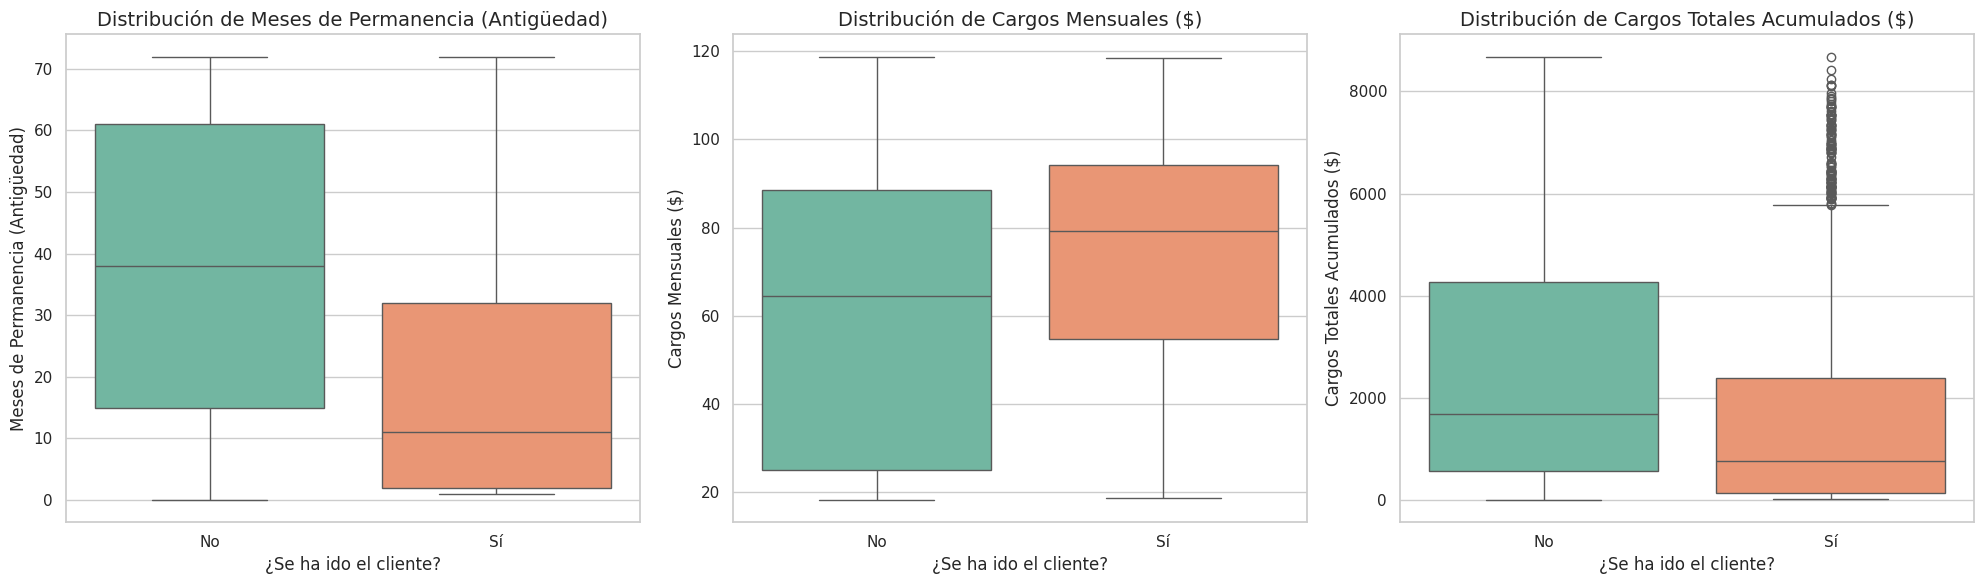

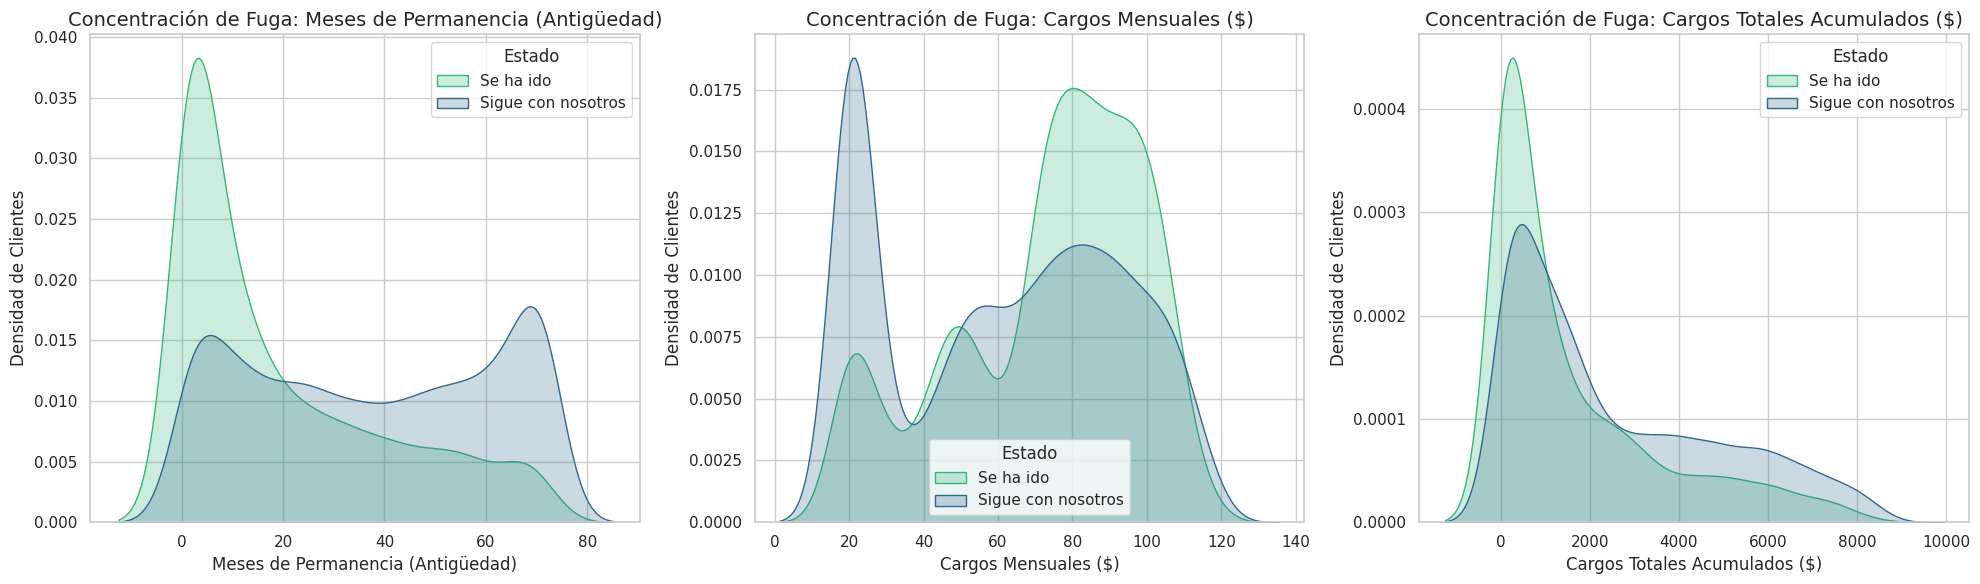

In [24]:
# Configuración de estilo y limpieza de warnings
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

# Definir variables numéricas clave
numeric_features = ['tenure', 'Charges.Monthly', 'Charges.Total']
traduc_num = {
    'tenure': 'Meses de Permanencia (Antigüedad)',
    'Charges.Monthly': 'Cargos Mensuales ($)',
    'Charges.Total': 'Cargos Totales Acumulados ($)'
}

# Crear visualizaciones comparativas (Boxplots)
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 6))

for i, col in enumerate(numeric_features):
    sns.boxplot(data=df, x='Churn', y=col, ax=axes[i], palette='Set2')
    axes[i].set_title(f'Distribución de {traduc_num[col]}', fontsize=14)
    axes[i].set_xlabel('¿Se ha ido el cliente?', fontsize=12)
    axes[i].set_ylabel(traduc_num[col], fontsize=12)
    axes[i].set_xticklabels(['No', 'Sí'])

plt.tight_layout()
plt.show()

# Análisis de densidad (KDE) para ver dónde se concentra la fuga
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 6))

for i, col in enumerate(numeric_features):
    sns.kdeplot(data=df, x=col, hue='Churn', fill=True, ax=axes[i], palette='viridis', common_norm=False)
    axes[i].set_title(f'Concentración de Fuga: {traduc_num[col]}', fontsize=14)
    axes[i].set_xlabel(traduc_num[col], fontsize=12)
    axes[i].set_ylabel('Densidad de Clientes', fontsize=12)
    axes[i].legend(title='Estado', labels=['Se ha ido', 'Sigue con nosotros'])

plt.tight_layout()
plt.show()

# 📄 Informe Ejecutivo: Análisis de Fuga de Clientes en TelecomX

## 1. Introducción
El objetivo principal de este análisis es identificar los factores clave que impulsan la pérdida de clientes (**Churn**) en TelecomX. A través del procesamiento de datos históricos de 7,267 usuarios, buscamos transformar datos crudos en hallazgos accionables para desarrollar estrategias de retención personalizadas y reducir la tasa de abandono.

## 2. Metodología y Preparación de Datos
Para garantizar un análisis preciso, se realizaron los siguientes procesos técnicos:
- **Desanidación de Datos**: Se expandieron objetos JSON complejos (`customer`, `phone`, `internet`, `account`) a un formato tabular.
- **Tipado y Limpieza**:
  - Conversión de variables categóricas ('Yes'/'No') a booleanas para optimizar el procesamiento.
  - Transformación de `Charges.Total` a numérico, gestionando valores nulos como 0.
- **Ingeniería de Variables**: Cálculo del cargo diario (`Cuentas_Diarias`) para normalizar el análisis de costos.

## 3. Análisis Exploratorio de Datos (EDA)
Tras visualizar las distribuciones generales, demográficas y de servicios, se identificaron patrones críticos:
- **Distribución de Antigüedad**: Se observa un riesgo de fuga extremadamente alto en los **primeros 6 meses** de permanencia.
- **Impacto Financiero**: Los clientes que cancelan el servicio tienden a tener **cargos mensuales significativamente más altos**.
- **Perfil Demográfico**: Los Adultos Mayores presentan mayor volatilidad, mientras que tener pareja o dependientes actúa como un factor de estabilidad.
- **Tecnología y Pago**: La **Fibra Óptica** y el método de pago por **Cheque Electrónico** están fuertemente correlacionados con una mayor tasa de abandono.

## 4. Conclusiones e Insights
- **Contratos de Corto Plazo**: El contrato 'Mes a Mes' es el principal predictor de fuga. La falta de compromiso a largo plazo facilita la salida del cliente ante cualquier insatisfacción.
- **Servicios de Valor Agregado**: Los clientes que cuentan con **Seguridad Online, Soporte Técnico y Protección de Dispositivos** muestran tasas de churn drásticamente menores, funcionando como 'anclas' de retención.
- **Sensibilidad al Precio**: La fuga se concentra en usuarios con planes costosos de fibra óptica que no perciben un valor proporcional o carecen de servicios de soporte incluidos.

## 5. Recomendaciones Estratégicas
1. **Migración de Contratos**: Implementar campañas de fidelización para transicionar a clientes 'Mes a Mes' hacia contratos anuales mediante descuentos progresivos.
2. **Empaquetamiento de Servicios (Bundling)**: Incluir servicios de Seguridad y Soporte Técnico de forma gratuita o subsidiada en los planes de Fibra Óptica para aumentar el valor percibido.
3. **Optimización de Pagos**: Incentivar el cambio de 'Cheque Electrónico' a métodos automáticos (Tarjeta de Crédito/Débito) mediante bonificaciones únicas, reduciendo la fricción mensual.
4. **Atención Temprana**: Crear un programa de 'Onboarding' para nuevos clientes durante los primeros 3 meses, asegurando que utilicen todos los beneficios del servicio desde el inicio.

In [25]:

df.to_csv("datos_tratados.csv", index=False)
